## Seasonality

In [1]:
import xarray as xr
from pathlib import Path
from xhistogram.xarray import histogram as xhist
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.patches as mpatches

In [2]:
from dask.distributed import Client
client = Client(n_workers=4, threads_per_worker=3, memory_limit=15e9)
client

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 42507 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:42507/status,
Dashboard: http://127.0.0.1:42507/status,Workers: 4
Total threads: 12,Total memory: 55.88 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42445,Workers: 0
Dashboard: http://127.0.0.1:42507/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33731,Total threads: 3
Dashboard: http://127.0.0.1:44289/status,Memory: 13.97 GiB
Nanny: tcp://127.0.0.1:41285,


2026-02-10 02:08:52,645 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:36633' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('rechunk-merge-524385c0d0098eedb345db0881ec2e45', 5679, 0, 0, 1), ('rechunk-split-83cf9a114d0a85b479da82fbabbd01e1', 2815), ('getitem-9ba8dc92b4af29c98ccef8873134aa87', 261, 0, 0, 0), ('rechunk-merge-524385c0d0098eedb345db0881ec2e45', 4212, 0, 0, 1), ('rechunk-merge-524385c0d0098eedb345db0881ec2e45', 5664, 0, 0, 1), ('getitem-9ba8dc92b4af29c98ccef8873134aa87', 234, 0, 1, 0), ('rechunk-merge-524385c0d0098eedb345db0881ec2e45', 5673, 0, 0, 1), ('rechunk-merge-524385c0d0098eedb345db0881ec2e45', 1299, 0, 0, 1), ('rechunk-split-83cf9a114d0a85b479da82fbabbd01e1', 1759), ('getitem-231efc8206e8bb25ed02dd380dd5bc0e', 47, 0, 1, 1), ('rechunk-merge-524385c0d0098eedb345db0881ec2e45', 3840, 0, 0, 1), ('rechunk-merge-524385c0d0098eedb345db0881ec2e45', 4215, 0, 0, 1), ('store-map-8fba44715861e706a557e6a81b276727',

In [3]:
!echo dask dashboard :D
!echo https://jupyterhub.dkrz.de/user/$USER/levante-spawner-preset/proxy/8787/status

dask dashboard :D
https://jupyterhub.dkrz.de/user/b383184/levante-spawner-preset/proxy/8787/status


In [4]:
ssh = xr.open_dataset('/work/bk1450/b383184/Amazon/Mercator/data/variables_c/tracers/SSH_1993-01c.nc')
ssh = ssh.compute()

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'sossheig' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


In [5]:
# U = xr.open_mfdataset('/work/bk1450/b383184/Amazon/Mercator/data/variables_c/UVW/U*.nc',chunks = {'time_counter':1}).isel(deptht=slice(0,7))
# U=U.chunk({'time_counter': 5, 'deptht': 7, 'y': 250, 'x': 600}).rename({'vozocrtx': 'U'})
U = xr.open_mfdataset(
    '/work/bk1450/b383184/Amazon/Mercator/data/variables_c/UVW/U*.nc',
    chunks={'time_counter':-1, 'deptht': 7, 'y': 250, 'x': 600},
).isel(deptht=slice(0, 7))
U = U.rename({"vozocrtx": "U"})
U

/tmp/ipykernel_1818971/3986624052.py:3: UserWarning: The specified chunks separate the stored chunks along dimension "y" starting at index 250. This could degrade performance. Instead, consider rechunking after loading.
  U = xr.open_mfdataset(
/tmp/ipykernel_1818971/3986624052.py:3: UserWarning: The specified chunks separate the stored chunks along dimension "x" starting at index 600. This could degrade performance. Instead, consider rechunking after loading.
  U = xr.open_mfdataset(
/tmp/ipykernel_1818971/3986624052.py:3: UserWarning: The specified chunks separate the stored chunks along dimension "y" starting at index 250. This could degrade performance. Instead, consider rechunking after loading.
  U = xr.open_mfdataset(
/tmp/ipykernel_1818971/3986624052.py:3: UserWarning: The specified chunks separate the stored chunks along dimension "x" starting at index 600. This could degrade performance. Instead, consider rechunking after loading.
  U = xr.open_mfdataset(
/tmp/ipykernel_18189

<xarray.Dataset> Size: 140GB
Dimensions:       (time_counter: 7973, deptht: 7, y: 499, x: 1260)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 64kB 1993-01-01T12:00:00 ... ...
    nav_lon       (y, x) float32 3MB dask.array<chunksize=(250, 600), meta=np.ndarray>
    nav_lat       (y, x) float32 3MB dask.array<chunksize=(250, 600), meta=np.ndarray>
  * x             (x) float64 10kB 2.306e+03 2.307e+03 ... 3.564e+03 3.565e+03
  * y             (y) float64 4kB 1.375e+03 1.376e+03 ... 1.872e+03 1.873e+03
  * deptht        (deptht) float32 28B 0.494 1.541 2.646 3.819 5.078 6.441 7.93
Data variables:
    U             (time_counter, deptht, y, x) float32 140GB dask.array<chunksize=(31, 7, 250, 600), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.2.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Thu Nov 06 16:54:50 2025: cdo setmissval,nan U_1993-01.nc /...
    CDO:          Climate Data Operators version 2.2.2 (https://mpimet.mpg.de...

In [6]:
# V = xr.open_mfdataset('/work/bk1450/b383184/Amazon/Mercator/data/variables_c/UVW/V*.nc',chunks = {'time_counter':1}).isel(deptht=slice(0,7))
# V=V.chunk({'time_counter': 5, 'deptht': 7, 'y': 250, 'x': 600}).rename({'vomecrty':'V'})
# V
V = xr.open_mfdataset(
    '/work/bk1450/b383184/Amazon/Mercator/data/variables_c/UVW/V*.nc',
    chunks={'time_counter':-1, 'deptht': 7, 'y': 250, 'x': 600},
).isel(deptht=slice(0, 7))
V = V.rename({"vomecrty": "V"})
V

/tmp/ipykernel_1818971/1397578570.py:4: UserWarning: The specified chunks separate the stored chunks along dimension "y" starting at index 250. This could degrade performance. Instead, consider rechunking after loading.
  V = xr.open_mfdataset(
/tmp/ipykernel_1818971/1397578570.py:4: UserWarning: The specified chunks separate the stored chunks along dimension "x" starting at index 600. This could degrade performance. Instead, consider rechunking after loading.
  V = xr.open_mfdataset(
/tmp/ipykernel_1818971/1397578570.py:4: UserWarning: The specified chunks separate the stored chunks along dimension "y" starting at index 250. This could degrade performance. Instead, consider rechunking after loading.
  V = xr.open_mfdataset(
/tmp/ipykernel_1818971/1397578570.py:4: UserWarning: The specified chunks separate the stored chunks along dimension "x" starting at index 600. This could degrade performance. Instead, consider rechunking after loading.
  V = xr.open_mfdataset(
/tmp/ipykernel_18189

<xarray.Dataset> Size: 140GB
Dimensions:       (time_counter: 7973, deptht: 7, y: 499, x: 1260)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 64kB 1993-01-01T12:00:00 ... ...
    nav_lon       (y, x) float32 3MB dask.array<chunksize=(250, 600), meta=np.ndarray>
    nav_lat       (y, x) float32 3MB dask.array<chunksize=(250, 600), meta=np.ndarray>
  * x             (x) float64 10kB 2.306e+03 2.307e+03 ... 3.564e+03 3.565e+03
  * y             (y) float64 4kB 1.375e+03 1.376e+03 ... 1.872e+03 1.873e+03
  * deptht        (deptht) float32 28B 0.494 1.541 2.646 3.819 5.078 6.441 7.93
Data variables:
    V             (time_counter, deptht, y, x) float32 140GB dask.array<chunksize=(31, 7, 250, 600), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.2.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Fri Nov 07 00:01:55 2025: cdo setmissval,nan V_1993-01.nc /...
    CDO:          Climate Data Operators version 2.2.2 (https://mpimet.mpg.de...

In [7]:
U_T = (U.U.shift(x=1) + U.U)*0.5

V_T = (V.V.shift(y=1) + V.V)*0.5

In [8]:
UV = xr.Dataset(
    data_vars={
        'U': (('time','depth','lat','lon'), U_T.data),
        'V': (('time','depth','lat', 'lon'), V_T.data),
    },
    coords={
        'time':U_T.time_counter.data,
        'depth':U_T.deptht.data,
        'lat':ssh.nav_lat.isel(x=0).data,
        'lon':ssh.nav_lon.isel(y=0).data,
    }
)
# UV['UV'] = (UV.U**2+UV.V**2)**0.5
# UV = UV.persist()
UV

<xarray.Dataset> Size: 281GB
Dimensions:  (time: 7973, depth: 7, lat: 499, lon: 1260)
Coordinates:
  * time     (time) datetime64[ns] 64kB 1993-01-01T12:00:00 ... 2014-12-31T12...
  * depth    (depth) float32 28B 0.494 1.541 2.646 3.819 5.078 6.441 7.93
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
Data variables:
    U        (time, depth, lat, lon) float32 140GB dask.array<chunksize=(31, 7, 250, 600), meta=np.ndarray>
    V        (time, depth, lat, lon) float32 140GB dask.array<chunksize=(31, 7, 250, 600), meta=np.ndarray>

#### Monthly anomalies

In [16]:
def monthly_anom(data):
    # 1) daily -> monthly mean (one value per month)
    mon = data.resample(time="MS").mean()   # "MS" = month start; use "M" for month end

    # 2) monthly climatology (12-month seasonal cycle)
    clim = mon.groupby("time.month").mean("time")

    # 3) anomalies
    anom = mon.groupby("time.month") - clim
    return anom
    
# def monthly_anom(data):    
#     season = data.groupby('time.month').mean(dim='time')
#     anom = data.groupby('time.month') - season
#     return anom

In [19]:
monthly_anom(UV).resample(time="MS").mean().drop_encoding().to_netcdf('UV_anom.nc')

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 32.71 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
2026-02-10 02:14:26,520 - distributed.worker - ERROR - failed during get data with tcp://127.0.0.1:44687 -> tcp://127.0.0.1:39605
Traceback (most recent call last):
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/tornado/iostream.py", line 861, in _read_to_buffer
    bytes_read = self.read_from_fd(buf)
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/tornado/iostream.py", line 1113, in read_from_fd
    return self.socket.recv_into(buf, len(buf))
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^

KilledWorker: Attempted to run task ('getitem-a543e281a8fb492bd8ec06e7ed78365a', 2029, 0, 1, 1) on 4 different workers, but all those workers died while running it. The last worker that attempt to run the task was tcp://127.0.0.1:35023. Inspecting worker logs is often a good next step to diagnose what went wrong. For more information see https://distributed.dask.org/en/stable/killed.html.

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 129.51 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


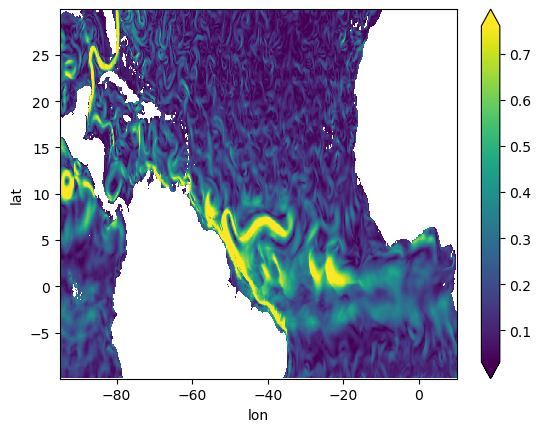

In [28]:
# UV.isel(time=0).load()

# rms_speed = ((UV.U.isel(time=slice(0,2))**2 + UV.V.isel(time=slice(0,2))**2).mean('time'))**0.5 
# rms_speed.load().mean('depth').plot(robust=True)

In [ ]:
uv = UV.UV.mean(dim='depth')
uv = uv.chunk({'time': 20, 'lat': -1, 'lon':-1})
uv=uv.persist()
uv
# uv.isel(time=0).load().plot()
# uv.drop_encoding().to_netcdf('UV_all_time.nc')
# uv.to_netcdf('UV_all_time.nc')

In [2]:
UV_mean = xr.open_dataset('UV_0_7m.nc')

In [3]:
def seasonality(data):    
    season = data.groupby('time.month').mean(dim='time')
    return season

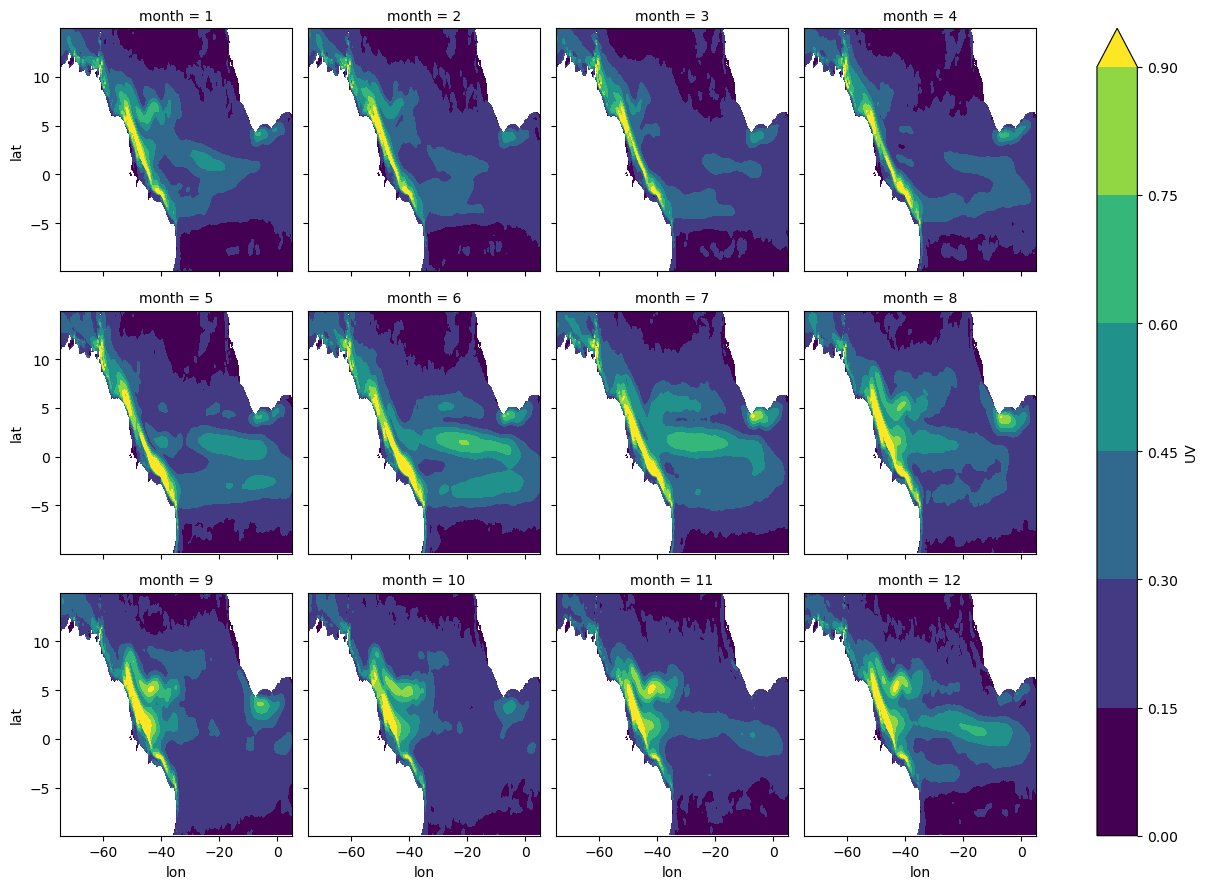

In [4]:
seasonality(UV_mean).UV.sel(lon=slice(-75,5),lat=slice(-10,15)).plot.contourf(x="lon", y="lat", col="month", col_wrap=4,robust=True)

In [5]:
def _std_(data):    
    time_std = data.groupby('time.month').std(dim='time')
    return time_std

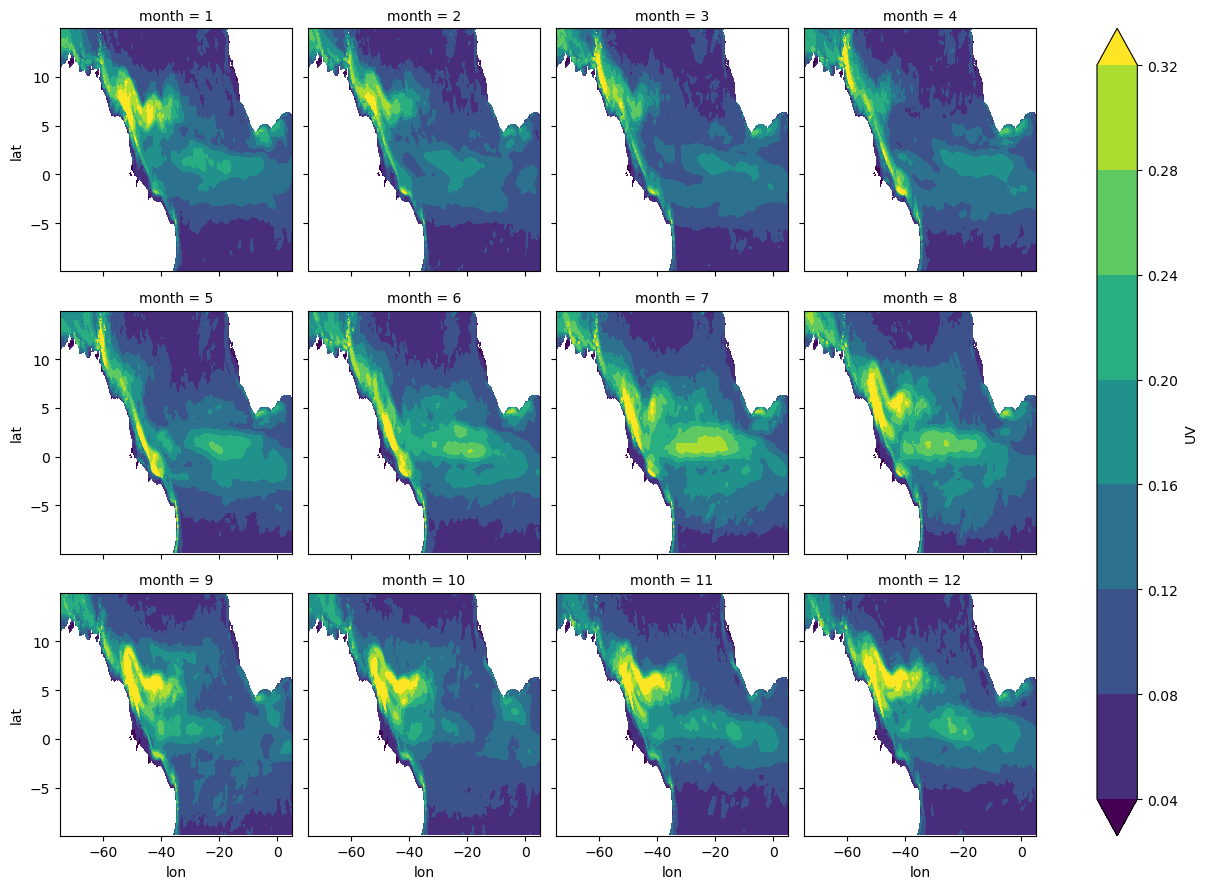

In [6]:
_std_(UV_mean).UV.sel(lon=slice(-75,5),lat=slice(-10,15)).plot.contourf(x="lon", y="lat", col="month", col_wrap=4,robust=True)